In [ ]:
#load RASP: 
from rasp import RASP
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from esda import Moran
from libpysal.weights import KNN

In [4]:
#set the parameters 

seed = 2024

#for DLPFC: 
kNN_threshold = 6
beta = 2
num_pcs = 20
n_neighbors = 10
n_clusters = 7
cluster_algorithm = 'mclust'
ground_truth = 'ground_truth'
platform = 'visium'

Before running this notebook, please make sure that you downloaded the DLPFC dataset from http://spatial.libd.org/spatialLIBD/
and ran the R notebook titled DLPFC_pre_processing_and_file_conversion.Rmd. 

In [ ]:
#The processed dataset is available to download in this folder "DLPFC_processed.h5ad"

# Replace with path to dataset on your machine 
adata = sc.read_h5ad(".../DLPFC_processed.h5ad")

#add the spatial coordinates to the object
coords = pd.read_csv(".../spatial_coordinates.csv")

adata.obsm['spatial'] = coords[['x_coord','y_coord']].values

In [ ]:
# Run RASP dimensionality reduction: randomized PCA followed by spatial smoothing.
# Note: this dataset was already normalized in R with SCTransform, so we run
# RASP directly on adata.X.
adata = RASP.reduce(
    adata,
    n_pcs=num_pcs,
    n_neighbors=kNN_threshold,
    beta=beta,
    platform=platform,
    random_state=seed,
)
# RASP.reduce writes the smoothed embedding to adata.obsm['X_pca_smoothed']
# and the PCA loadings to adata.varm['RASP_PCs'].

In [ ]:
#build the neighbors graph on the RASP embedding, then cluster
sc.pp.neighbors(adata, n_neighbors=n_neighbors, use_rep='X_pca_smoothed')

In [13]:
#cluster
adata = RASP.clustering(adata, n_clusters=n_clusters, n_neighbors = n_neighbors,key='X_pca_smoothed', method=cluster_algorithm)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [14]:
#prepare object for plotting and print ARI 
coords = adata.obsm['spatial']
ground_truth_labels = adata.obs[ground_truth].astype(str)
labels = adata.obs[f'RASP_{cluster_algorithm}_clusters'].astype(str)
ari = adjusted_rand_score(ground_truth_labels, labels)
CHAOS = RASP.CHAOS(labels, coords)

print(f"ARI: {ari}")
print(f"CHAOS: {CHAOS}")

#calculate Moran's I: 
w = KNN(coords, k=10)
unique_labels, labels_numeric = np.unique(labels, return_inverse=True)
moran = Moran(labels_numeric, w).I
print(f"Moran's I: {moran}")

ARI: 0.611713533584195
CHAOS: 0.06082358388224196
Moran's I: 0.7157181854829612


/dartfs-hpc/rc/lab/F/FrostH/members/igingerich/envs/miniconda3/envs/r-kernel/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:955: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


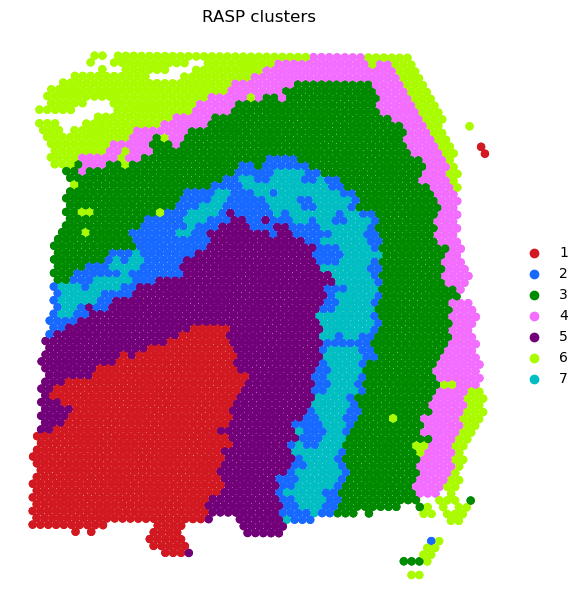

In [15]:
sq.pl.spatial_scatter(adata,
    color=[f'RASP_{cluster_algorithm}_clusters'],
    frameon=False,
    shape=None,
    figsize = (6,6),
    ncols = 2,
    size = 100,
    use_raw = False,title = "RASP clusters")

In [ ]:
#now for the reconstruction code (reconstruct single stage RASP only):

#reconstruct a specific gene from the spatially smoothed reduced-rank dims
#computed by RASP.reduce above: the smoothed embedding is in
#adata.obsm['X_pca_smoothed'] and the PCA loadings are in adata.varm['RASP_PCs'].

visium_gene_example = 'TMSB10'
adata = RASP.reconstruct_gene(adata, 
                         adata.obsm['X_pca_smoothed'], 
                         adata.varm['RASP_PCs'].T,
                         gene_name=visium_gene_example, 
                         quantile_prob=0.001,
                         scale = False,
                         threshold_method = 'ALRA',
                         rank_k = 20)

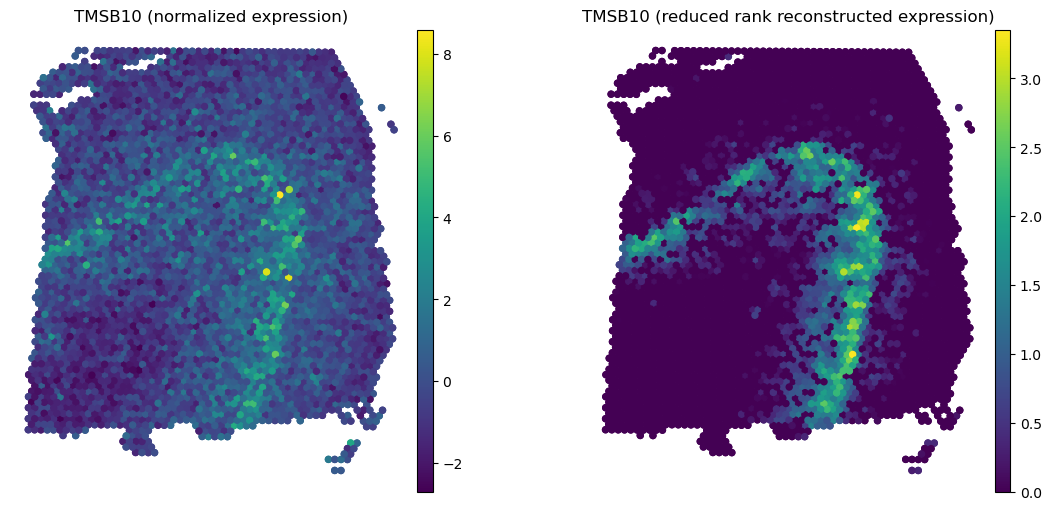

In [17]:
sq.pl.spatial_scatter(
    adata,
    color=[f'{visium_gene_example}',f'restored_{visium_gene_example}'],
    frameon=False,
    shape=None,
    figsize = (6,6),
    ncols = 2,
    size = 75,
    use_raw = False, 
    title = [f'{visium_gene_example} (normalized expression)',
             f'{visium_gene_example} (reduced rank reconstructed expression)']
    
)

In [30]:
import igraph
print(igraph.__version__)

0.11.5
